##**Load Training Dataframe**

In [10]:
import pandas as pd
import numpy as np

# Load training data
user_df = pd.read_csv("training_features_with_labels.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_features = user_df[feature_cols].values
y_labels = user_df["label"].values

In [11]:
# Random seed for reproducibility
RANDOM_SEED = 42

##**Supervised Model I – Logistic Regression**

Expectation: this model may not perform very well, as it is a simple linear model that can only learn linear decision boundaries.

It can be used as a **simple baseline** to compare other models against

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

**Train the model**

In [13]:
# Tunable parameters:
regularization_strength = 1.0

# Logistic Regression is sensitive to feature scales, so we need to standardize the data
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",    # handles imbalanced classes
        max_iter=1000,              # ensure convergence
        C=regularization_strength,  # regularization strength (lower = more regularization)
        random_state=RANDOM_SEED
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

lr_scores = []
lr_precision = []
lr_recall = []
lr_f1 = []

for train_idx, val_idx in skf.split(X_features, y_labels):
    X_train, X_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]

    lr_pipeline.fit(X_train, y_train)
    y_prob = lr_pipeline.predict_proba(X_val)[:, 1]  # P(anomalous)
    y_pred = lr_pipeline.predict(X_val) # Predicted classes

    lr_scores.append(roc_auc_score(y_val, y_prob))
    lr_precision.append(precision_score(y_val, y_pred))
    lr_recall.append(recall_score(y_val, y_pred))
    lr_f1.append(f1_score(y_val, y_pred))

print(f"Logistic Regression AUC: {np.mean(lr_scores):.4f} ± {np.std(lr_scores):.4f}")
print(f"Logistic Regression Precision: {np.mean(lr_precision):.4f} ± {np.std(lr_precision):.4f}")
print(f"Logistic Regression Recall: {np.mean(lr_recall):.4f} ± {np.std(lr_recall):.4f}")
print(f"Logistic Regression F1 Score: {np.mean(lr_f1):.4f} ± {np.std(lr_f1):.4f}")

Logistic Regression AUC: 0.8701 ± 0.0205
Logistic Regression Precision: 0.2930 ± 0.0213
Logistic Regression Recall: 0.7600 ± 0.0490
Logistic Regression F1 Score: 0.4219 ± 0.0212


Based on the training with regularization strength = 1.0, the model performs reasonably well with a mean AUC score of 0.87. We can move on to train the model on the full dataset. ‼️ draw insight from the scores calculated and what can be inferred about the model

**Inspect coefficients**

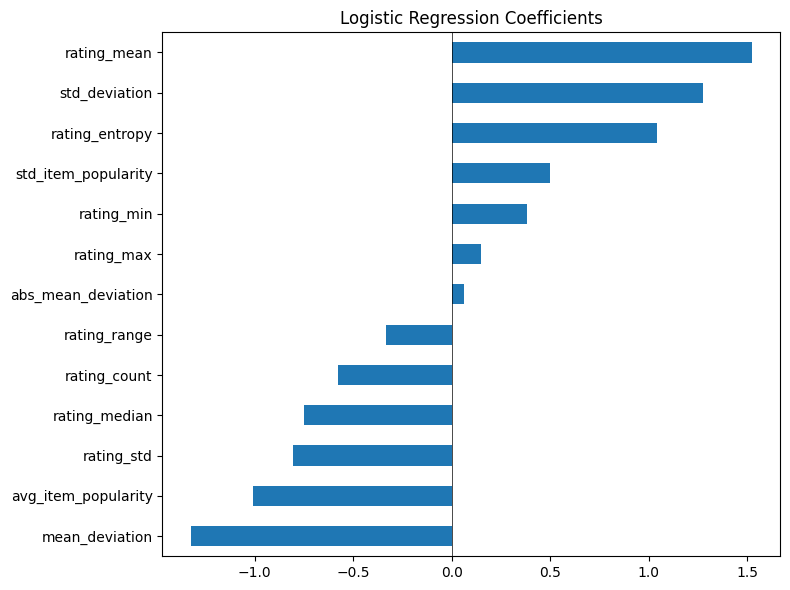

In [14]:
import matplotlib.pyplot as plt

# Train on full data for inspection
lr_pipeline.fit(X_features, y_labels)

# Get coefficients (higher absolute value = more influential)
coefs = pd.Series(
    lr_pipeline.named_steps["lr"].coef_[0],
    index=feature_cols
).sort_values()

# Visualise coefficients
fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot.barh(ax=ax)
ax.set_title("Logistic Regression Coefficients")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

Positive coefficients push toward "anomalous," while negative ones push toward "normal."

**Test Logistic Regression model**

In [15]:
# Load test data
test_df = pd.read_csv("test_features.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_test = test_df[feature_cols].values

# Predict scores on test data
y_score = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"# of predictions:     {len(y_score)}")
print(f"Sample scores:        {y_score[:5]}")

# Save as submission.npz
np.savez('logistic_regression.npz', predictions=y_score)

# of predictions:     220
Sample scores:        [0.47424283 0.06452175 0.31065052 0.5124994  0.15022385]


**Results from Codabench:**


In [16]:
# AUC:       0.8713
# Precision: 0.1731
# Recall:    1.0000
# F1 Score:  0.2951

An AUC score of 0.8713 shows that the model has strong class separation ability. However, the low precision score (17.31%) means that about 82.7% of flagged cases are false positives. The model is aggressive in labeling positives to avoid missing any anomalies.

##**Supervised Model II – MLP**

Expectation: MLP should perform better than the Logistic Regression model as it is more flexible and can learn nonlinear patterns within the data

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# Tunable paramters:
val_split = 0.15
initial_learning_rate = 0.001

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),                  # two hidden layers: 64 neurons then 32
        activation="relu",                            # standard activation function
        max_iter=500,                                 # training epochs
        early_stopping=True,                          # stop if validation score stops improving
        validation_fraction=val_split,                # use val_split% of training data for validation and early stopping
        learning_rate_init=initial_learning_rate,     # starting learning rate
        random_state=RANDOM_SEED
    ))
])

# To handle imblanace, oversample anomalous users with SMOTE
mlp_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_SEED)),  # creates synthetic anomalous samples
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        validation_fraction=val_split,
        learning_rate_init=initial_learning_rate,
        random_state=RANDOM_SEED
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

mlp_scores = []
mlp_smote_scores = []

for train_idx, val_idx in skf.split(X_features, y_labels):
    X_train, X_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]

    mlp_pipeline.fit(X_train, y_train)
    y_prob = mlp_pipeline.predict_proba(X_val)[:, 1]
    y_pred = mlp_pipeline.predict(X_val)
    mlp_scores.append(roc_auc_score(y_val, y_prob))

    mlp_smote_pipeline.fit(X_train, y_train)
    y_prob_smote = mlp_smote_pipeline.predict_proba(X_val)[:, 1]
    y_pred_smote = mlp_smote_pipeline.predict(X_val)
    mlp_smote_scores.append(roc_auc_score(y_val, y_prob_smote))


print(f"MLP AUC: {np.mean(mlp_scores):.4f} ± {np.std(mlp_scores):.4f}")
print(f"MLP SMOTE AUC: {np.mean(mlp_smote_scores):.4f} ± {np.std(mlp_smote_scores):.4f}")

MLP AUC: 0.8526 ± 0.0503
MLP SMOTE AUC: 0.9135 ± 0.0241


SMOTE generates synthetic anomalous users by interpolating between existing anomalois samples, in an attempt to provide the MLP with a balanced dataset during training.

**Train MLP models (with and without SMOTE)**

In [ ]:
# Train MLP and MLP_SMOTE on full data
mlp_pipeline.fit(X_features, y_labels)
mlp_smote_pipeline.fit(X_features, y_labels)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"


**Analyse the MLP model (without SMOTE)** ‼️ explain t-SNE

C:\Users\User\AppData\Local\Temp\ipykernel_68440\3287067562.py:27: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])


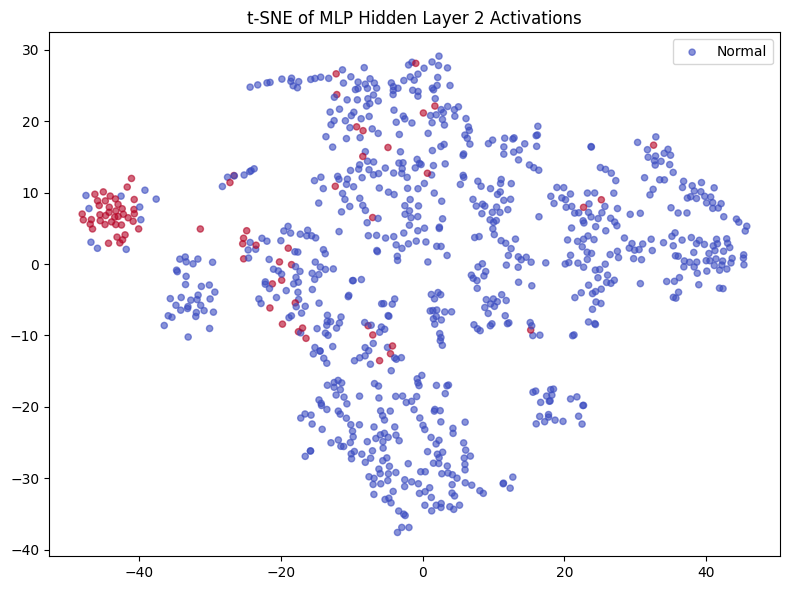

In [ ]:
from sklearn.manifold import TSNE

# Extract the scaler and trained MLP
scaler = mlp_pipeline.named_steps["scaler"]
mlp = mlp_pipeline.named_steps["mlp"]

# Scale the input the same way the pipeline does
X_scaled = scaler.transform(X_train)

# Manually pass data through hidden layers to get activations
# Layer 1 output
hidden1 = np.maximum(0, X_scaled @ mlp.coefs_[0] + mlp.intercepts_[0])  # ReLU
# Layer 2 output
hidden2 = np.maximum(0, hidden1 @ mlp.coefs_[1] + mlp.intercepts_[1])   # ReLU

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(hidden2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    embeddings[:, 0], embeddings[:, 1],
    c=y_train, cmap="coolwarm", alpha=0.6, s=20
)
ax.set_title("t-SNE of MLP Hidden Layer 2 Activations")
ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

The anomalies generally form one cluster on the left, but there are still some anomalous points within the normal cluster. The model is likely to misclassify these anomalous points.

**Test MLP models**

In [ ]:
# Load test data
test_df = pd.read_csv("test_features.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_test = test_df[feature_cols].values

# Predict scores on test data
y_score = mlp_pipeline.predict_proba(X_test)[:, 1]
y_score_smote = mlp_smote_pipeline.predict_proba(X_test)[:, 1]

print(f"# of predictions:       {len(y_score)}")
print(f"Sample scores:          {y_score[:5]}")
print(f"Sample scores (SMOTE):  {y_score_smote[:5]}")

# Save as submission.npz
np.savez('mlp.npz', predictions=y_score)
np.savez('mlp_smote.npz', predictions=y_score_smote)

# of predictions:       220
Sample scores:          [5.55245838e-05 5.75725472e-06 1.11901322e-04 6.87870535e-05
 4.89598260e-05]
Sample scores (SMOTE):  [2.86916642e-05 5.45355705e-04 3.35455457e-06 1.15724371e-05
 1.29055134e-06]


**Results from Codabench:**


In [ ]:
# MLP:
# AUC:       0.7761
# Precision: 0.0000
# Recall:    0.0000
# F1 Score:  0.0000

In [ ]:
# MLP_SMOTE:
# AUC:       0.7272
# Precision: 0.0000
# Recall:    0.0000
# F1 Score:  0.0000

### Teammate Iteration - Ky
Problem with current MLP model:
- badly overfits (0.913 CV → 0.776 test) -> L2 Regularization (smooth out features)
- Scores are essentially 0 -> no correct prediction -> mlp collapsed into trivial solution of predicting all as normal user

While the class imbalance should have been tackled with smote, result says otherwise. However, I noted weight was not being utilised. We can emphasise to the model that identify is more important with class_weight in the loss function. **smote $\neq$ class_weight**

Metrics Definition for Ky (ignnore pls)

- Accuracy: Fraction of correct predictions
- Precision: all predicted positives, how many are actually positive ? 
- Recall: all actual positives, how many were correctly detected ?

MLP AUC: 0.8807 ± 0.0290
MLP SMOTE AUC: 0.8785 ± 0.0232


C:\Users\User\AppData\Local\Temp\ipykernel_68440\4261347689.py:95: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])


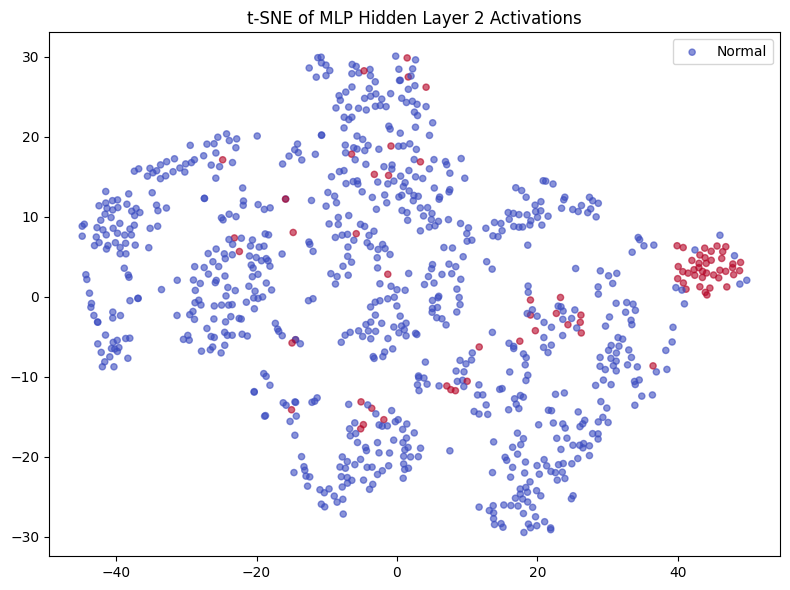

# of predictions:       220
Sample scores:          [0.05216754 0.01444995 0.03232036 0.0712756  0.02275124]
Sample scores (SMOTE):  [0.3801306  0.17522313 0.32119702 0.40461281 0.29051224]


In [ ]:
# Tunable paramters:
from sklearn.utils import compute_sample_weight


val_split = 0.15
initial_learning_rate = 0.001
ridge_alpha = 0.1
ridge_alpha_smote = 10

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),                  # two hidden layers: 64 neurons then 32
        activation="relu",                            # standard activation function
        max_iter=500,                                 # training epochs
        early_stopping=True,                          # stop if validation score stops improving
        validation_fraction=val_split,                # use val_split% of training data for validation and early stopping
        learning_rate_init=initial_learning_rate,     # starting learning rate
        random_state=RANDOM_SEED,
        alpha=ridge_alpha
    ))
])

# To handle imblanace, oversample anomalous users with SMOTE
mlp_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=3)),  # creates synthetic anomalous samples
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        validation_fraction=val_split,
        learning_rate_init=initial_learning_rate,
        random_state=RANDOM_SEED,
        alpha=ridge_alpha_smote
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

mlp_scores = []
mlp_smote_scores = []

for train_idx, val_idx in skf.split(X_features, y_labels):
    X_train, X_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    fold_weights = compute_sample_weight(class_weight="balanced", y=y_train) # compute weights for this fold
    mlp_pipeline.fit(X_train, y_train, mlp__sample_weight=fold_weights) # pass weights to MLP
    y_prob = mlp_pipeline.predict_proba(X_val)[:, 1]
    y_pred = mlp_pipeline.predict(X_val)
    mlp_scores.append(roc_auc_score(y_val, y_prob))

    mlp_smote_pipeline.fit(X_train, y_train)
    y_prob_smote = mlp_smote_pipeline.predict_proba(X_val)[:, 1]
    y_pred_smote = mlp_smote_pipeline.predict(X_val)
    mlp_smote_scores.append(roc_auc_score(y_val, y_prob_smote))


print(f"MLP AUC: {np.mean(mlp_scores):.4f} ± {np.std(mlp_scores):.4f}")
print(f"MLP SMOTE AUC: {np.mean(mlp_smote_scores):.4f} ± {np.std(mlp_smote_scores):.4f}")

# Train MLP and MLP_SMOTE on full data
sample_weights = compute_sample_weight(class_weight="balanced", y=y_labels)
mlp_pipeline.fit(X_features, y_labels, mlp__sample_weight=sample_weights)
mlp_smote_pipeline.fit(X_features, y_labels)

from sklearn.manifold import TSNE

# Extract the scaler and trained MLP
scaler = mlp_pipeline.named_steps["scaler"]
mlp = mlp_pipeline.named_steps["mlp"]

# Scale the input the same way the pipeline does
X_scaled = scaler.transform(X_train)

# Manually pass data through hidden layers to get activations
# Layer 1 output
hidden1 = np.maximum(0, X_scaled @ mlp.coefs_[0] + mlp.intercepts_[0])  # ReLU
# Layer 2 output
hidden2 = np.maximum(0, hidden1 @ mlp.coefs_[1] + mlp.intercepts_[1])   # ReLU

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(hidden2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    embeddings[:, 0], embeddings[:, 1],
    c=y_train, cmap="coolwarm", alpha=0.6, s=20
)
ax.set_title("t-SNE of MLP Hidden Layer 2 Activations")
ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

# Load test data
test_df = pd.read_csv("test_features.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_test = test_df[feature_cols].values

# Predict scores on test data
y_score = mlp_pipeline.predict_proba(X_test)[:, 1]
y_score_smote = mlp_smote_pipeline.predict_proba(X_test)[:, 1]

print(f"# of predictions:       {len(y_score)}")
print(f"Sample scores:          {y_score[:5]}")
print(f"Sample scores (SMOTE):  {y_score_smote[:5]}")

In [ ]:
# Load test users from the trial test file
test_data = np.load("subset_training_batch.npz")
X_test_raw = test_data["X"]
test_users = np.unique(X_test_raw[:, 0])

# Load ground truth labels from training file
train_data = np.load("training_batch_with_labels.npz")
all_labels = pd.DataFrame(train_data["y"], columns=["user", "label"])

test_df = pd.read_csv("test_features.csv")
test_labels = test_df[["user"]].merge(all_labels, on="user")["label"].values

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(test_labels, y_score)  # y_score = your model's predictions
auc_smote = roc_auc_score(test_labels, y_score_smote)
print(f"Local AUC (MLP): {auc:.4f}")
print(f"Local AUC (MLP SMOTE): {auc_smote:.4f}")

# Save as submission.npz
# np.savez('mlp.npz', predictions=y_score)
np.savez('mlp_smote_v2.npz', predictions=y_score_smote)

Local AUC (MLP): 0.7506
Local AUC (MLP SMOTE): 0.8982


### What's new: 
#### Tuned L2 reg alpha for both:
- alpha=0.1 (MLP): weighted L2 → less overfitting, weights stay smaller
- alpha=10 (MLP SMOTE): more regularization to counteract SMOTE's tendency to overfit synthetic samples
- k_neighbors=3: SMOTE interpolates between the 3 nearest anomalous neighbors instead of 5 -> tighter, more realistic synthetic samples
> MLP_SMOTE score incerased to 0.898

### sample weight for none Smote MLP
- Forces the MLP model to care more about getting anomalies right
> MLP peaked at 0.75, minimal improvement compared to smote

> Submitted score 0.90 - **sorry I forgot to get the other score lol**

# Teammate iteration: Kamiya 
Used xgboost + lightgbm 


In [46]:
!pip install lightgbm
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import rankdata
import warnings
warnings.filterwarnings("ignore")

# ============================================
# LOAD ENGINEERED TRAIN FEATURES
# ============================================
train_df = pd.read_csv("training_features_with_labels.csv")

feature_cols = [c for c in train_df.columns if c not in ["user", "label"]]

X = train_df[feature_cols].values
y = train_df["label"].values

# ============================================
# HOLD OUT A TEST SET BEFORE ANY TRAINING
# ============================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================
# FEATURE SCALING
# ============================================
scaler = RobustScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled = scaler.transform(X_test)

# ============================================
# HELPER: build models
# early_stopping_rounds is in the constructor for XGBoost >= 2.0
# ============================================
def make_xgb(scale_pos_weight, seed=42):
    return xgb.XGBClassifier(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        colsample_bylevel=0.7,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        early_stopping_rounds=50,   # <-- moved here (XGBoost >= 2.0)
        random_state=seed,
        n_jobs=-1,
    )


def make_lgb(scale_pos_weight, seed=42):
    return lgb.LGBMClassifier(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.5,
        scale_pos_weight=scale_pos_weight,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )


# ============================================
# CROSS VALIDATION — XGB + LGB + Ensemble
# ============================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs_xgb, aucs_lgb, aucs_ens = [], [], []
oof_xgb = np.zeros(len(X_trainval))
oof_lgb = np.zeros(len(X_trainval))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval_scaled, y_trainval)):
    X_tr, X_val = X_trainval_scaled[train_idx], X_trainval_scaled[val_idx]
    y_tr, y_val = y_trainval[train_idx], y_trainval[val_idx]

    neg_count = np.sum(y_tr == 0)
    pos_count = np.sum(y_tr == 1)
    spw = neg_count / pos_count

    # --- XGBoost (early_stopping_rounds in constructor, not fit()) ---
    xgb_model = make_xgb(spw)
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    p_xgb = xgb_model.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = p_xgb

    # --- LightGBM ---
    lgb_model = make_lgb(spw)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    p_lgb = lgb_model.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = p_lgb

    # --- Rank-average ensemble ---
    p_ens = (rankdata(p_xgb) + rankdata(p_lgb)) / 2

    auc_xgb = roc_auc_score(y_val, p_xgb)
    auc_lgb = roc_auc_score(y_val, p_lgb)
    auc_ens = roc_auc_score(y_val, p_ens)

    aucs_xgb.append(auc_xgb)
    aucs_lgb.append(auc_lgb)
    aucs_ens.append(auc_ens)

    print(f"Fold {fold+1}:  XGB={auc_xgb:.4f}  LGB={auc_lgb:.4f}  Ensemble={auc_ens:.4f}")

# OOF ensemble AUC
oof_ens = (rankdata(oof_xgb) + rankdata(oof_lgb)) / 2
oof_auc = roc_auc_score(y_trainval, oof_ens)

print("\n=== CV Results ===")
print(f"XGBoost  AUC: {np.mean(aucs_xgb):.4f} ± {np.std(aucs_xgb):.4f}")
print(f"LightGBM AUC: {np.mean(aucs_lgb):.4f} ± {np.std(aucs_lgb):.4f}")
print(f"Ensemble AUC: {np.mean(aucs_ens):.4f} ± {np.std(aucs_ens):.4f}")
print(f"OOF Ensemble: {oof_auc:.4f}")

# ============================================
# FINAL MODELS — trained on all trainval data
# ============================================
neg_count = np.sum(y_trainval == 0)
pos_count = np.sum(y_trainval == 1)
spw = neg_count / pos_count

# Use 10% of trainval as early-stopping signal for final models
X_ft, X_es, y_ft, y_es = train_test_split(
    X_trainval_scaled, y_trainval, test_size=0.1, stratify=y_trainval, random_state=42
)

final_xgb = make_xgb(spw)
final_xgb.fit(
    X_ft, y_ft,
    eval_set=[(X_es, y_es)],
    verbose=False,
)

final_lgb = make_lgb(spw)
final_lgb.fit(
    X_ft, y_ft,
    eval_set=[(X_es, y_es)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

# ============================================
# EVALUATE ON HELD-OUT TEST SET
# ============================================
p_xgb_test = final_xgb.predict_proba(X_test_scaled)[:, 1]
p_lgb_test = final_lgb.predict_proba(X_test_scaled)[:, 1]
y_score = (rankdata(p_xgb_test) + rankdata(p_lgb_test)) / 2

# ── Threshold search on normalised OOF scores ────────────────────────────────
# Normalise OOF rank-ensemble to [0, 1] so thresholds are comparable
oof_ens_norm = (oof_ens - oof_ens.min()) / (oof_ens.max() - oof_ens.min() + 1e-9)

thresholds = np.linspace(0.01, 0.99, 500)
j_scores, prec_scores, rec_scores, f1_scores_t = [], [], [], []

for t in thresholds:
    preds_t = (oof_ens_norm >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    prec_scores.append(prec)
    rec_scores.append(sens)
    f1_scores_t.append(f1_t)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)
best_threshold_j  = thresholds[best_j_idx]
best_threshold_f1 = thresholds[best_f1_idx]

print(f"\nOptimal threshold — Youden's J : {best_threshold_j:.3f}  "
      f"(prec={prec_scores[best_j_idx]:.3f}, rec={rec_scores[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {best_threshold_f1:.3f}  "
      f"(prec={prec_scores[best_f1_idx]:.3f}, rec={rec_scores[best_f1_idx]:.3f})")

# Missed positives are more acceptable → optimise for precision via best F1
best_threshold = best_threshold_f1

# Apply same normalisation to test scores before thresholding
y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-9)
y_pred = (y_score_norm >= best_threshold).astype(int)

auc       = roc_auc_score(y_test, y_score)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print("\n# XGB + LGB Ensemble (held-out test set):")
print(f"# AUC:       {auc:.4f}")
print(f"# Precision: {precision:.4f}")
print(f"# Recall:    {recall:.4f}")
print(f"# F1 Score:  {f1:.4f}")

# ============================================
# TRIAL PHASE SUBMISSION — subset_training_batch.npz
# ============================================
import zipfile, os

# Load trial test users
test_data  = np.load("subset_training_batch.npz")
X_test_raw = test_data["X"]
test_users = np.unique(X_test_raw[:, 0])

# Load engineered features for those users
test_df    = pd.read_csv("test_features.csv")
X_unseen   = scaler.transform(test_df[feature_cols].values)

# Score with ensemble
p_xgb_u        = final_xgb.predict_proba(X_unseen)[:, 1]
p_lgb_u        = final_lgb.predict_proba(X_unseen)[:, 1]
y_unseen_score = (rankdata(p_xgb_u) + rankdata(p_lgb_u)) / 2

# Local AUC check (requires labels in training_batch_with_labels.npz)
try:
    train_data = np.load("training_batch_with_labels.npz")
    all_labels = pd.DataFrame(train_data["y"], columns=["user", "label"])
    test_labels = test_df[["user"]].merge(all_labels, on="user")["label"].values
    local_auc = roc_auc_score(test_labels, y_unseen_score)
    print(f"\nLocal AUC (trial set): {local_auc:.4f}")
except Exception as e:
    print(f"\nCould not compute local AUC: {e}")

# Save predictions as .npz  (key must be 'predictions')
npz_path = "submission.npz"
# Normalise to [0,1] before saving (AUC is rank-invariant but avoids warnings)
y_unseen_norm = (y_unseen_score - y_unseen_score.min()) / (y_unseen_score.max() - y_unseen_score.min())
np.savez(npz_path, predictions=y_unseen_norm)

# Zip into submission.zip
zip_path = "submission.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(npz_path, arcname="submission.npz")

print(f"Saved {npz_path} and zipped to {zip_path} — upload submission.zip to Codabench")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fold 1:  XGB=0.8762  LGB=0.9059  Ensemble=0.8947
Fold 2:  XGB=0.8852  LGB=0.8859  Ensemble=0.8914
Fold 3:  XGB=0.9586  LGB=0.9586  Ensemble=0.9627
Fold 4:  XGB=0.8961  LGB=0.8859  Ensemble=0.8943
Fold 5:  XGB=0.9010  LGB=0.9262  Ensemble=0.9268

=== CV Results ===
XGBoost  AUC: 0.9034 ± 0.0289
LightGBM AUC: 0.9125 ± 0.0274
Ensemble AUC: 0.9140 ± 0.0276
OOF Ensemble: 0.9106

Optimal threshold — Youden's J : 0.739  (prec=0.347, rec=0.837)
Optimal threshold — Best F1   : 0.915  (prec=0.742, rec=0.612)

# XGB + LGB Ensemble (held-out test set):
# AUC:       0.9535
# Precision: 0.7368
# Recall:    0.7000
# F1 Score:  0.7179

Local AUC (trial set): 0.9900
Saved submission.npz and zipped to submission.zip — upload submission.zip to Codabench
